# CNN Training Strategy 3: Curriculum Learning (Prediction Difficulty)

CIFAR-10: 60,000 32x32 colour images in 10 classes
- 50,000 training images | 10,000 test images
- Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

**Strategy**: Curriculum Learning based on prediction difficulty.

1. First, train a "scorer" model briefly on the full dataset to assess sample difficulty.
2. Rank all training samples by their loss (low loss = easy, high loss = hard).
3. Train the final model in stages, starting with the easiest samples and progressively
   introducing harder ones:
   - Stage 1: Easiest 20% (5 epochs)
   - Stage 2: Easiest 40% (5 epochs)
   - Stage 3: Easiest 60% (5 epochs)
   - Stage 4: Easiest 80% (5 epochs)
   - Stage 5: All 100% (5 epochs)

Total: 25 epochs — same as the full dataset strategy.

### Importing the libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [3]:
tf.__version__

'2.19.0'

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## Part 1 - Data Preprocessing

### Loading the CIFAR-10 dataset

In [9]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

### Preprocessing the Test set

In [11]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow(x_test, y_test, batch_size=64)

### Define the training data augmentation pipeline

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

## Part 2 - Building the CNN

Same architecture as the full dataset training strategy.

In [17]:
def build_cnn():
    cnn = models.Sequential()
    
    # First Convolution + Pooling
    cnn.add(layers.Input(shape=(32, 32, 3)))
    cnn.add(layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
    cnn.add(layers.BatchNormalization())
    cnn.add(layers.MaxPool2D(pool_size=2, strides=2))
    
    # Second Convolution + Pooling
    cnn.add(layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
    cnn.add(layers.BatchNormalization())
    cnn.add(layers.MaxPool2D(pool_size=2, strides=2))
    
    # Third Convolution + Pooling
    cnn.add(layers.Conv2D(filters=128, kernel_size=3, activation='relu'))
    cnn.add(layers.BatchNormalization())
    cnn.add(layers.MaxPool2D(pool_size=2, strides=2))
    
    # Flattening
    cnn.add(layers.Flatten())
    
    # Full Connection
    cnn.add(layers.Dense(units=256, activation='relu'))
    cnn.add(layers.Dropout(0.5))
    cnn.add(layers.Dense(units=128, activation='relu'))
    cnn.add(layers.Dropout(0.3))
    
    # Output Layer
    cnn.add(layers.Dense(units=10, activation='softmax'))
    
    return cnn

## Part 3 - Scoring Samples by Difficulty

We train a quick "scorer" model for a few epochs to compute the per-sample loss.
Samples with **low loss** are considered "easy" and samples with **high loss** are "hard".
This ranking is then used to order the training data from easy to hard.

In [19]:
print("Building scorer model to assess sample difficulty...")
scorer = build_cnn()
scorer.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the scorer for a small number of epochs (just enough to get meaningful difficulty scores)
scorer_train_set = train_datagen.flow(x_train, y_train, batch_size=64)
scorer.fit(x=scorer_train_set, epochs=3, verbose=1)

print("\nScorer training complete.")

Building scorer model to assess sample difficulty...
Epoch 1/3


D:\ANACONDA\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.2798 - loss: 2.0421
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.4468 - loss: 1.5366
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.5176 - loss: 1.3670

Scorer training complete.


In [21]:
# Compute per-sample loss using the scorer model
print("Computing per-sample difficulty scores...")

# Normalize training images for prediction
x_train_normalized = x_train.astype('float32') / 255.0

# Get predictions from scorer
predictions = scorer.predict(x_train_normalized, batch_size=256, verbose=1)

# Compute per-sample cross-entropy loss
# loss = -log(predicted_probability_of_true_class)
per_sample_loss = np.zeros(len(x_train))
for i in range(len(x_train)):
    true_label = int(y_train[i][0])
    pred_prob = predictions[i][true_label]
    # Clip to avoid log(0)
    pred_prob = np.clip(pred_prob, 1e-7, 1.0)
    per_sample_loss[i] = -np.log(pred_prob)

print(f"\nDifficulty score statistics:")
print(f"  Min loss (easiest):  {per_sample_loss.min():.4f}")
print(f"  Max loss (hardest):  {per_sample_loss.max():.4f}")
print(f"  Mean loss:           {per_sample_loss.mean():.4f}")
print(f"  Median loss:         {np.median(per_sample_loss):.4f}")

Computing per-sample difficulty scores...
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step

Difficulty score statistics:
  Min loss (easiest):  0.0001
  Max loss (hardest):  10.5811
  Mean loss:           1.2051
  Median loss:         0.9675


In [23]:
# Sort training data by difficulty (easy first, hard last)
difficulty_order = np.argsort(per_sample_loss)  # ascending order: easy → hard

x_train_sorted = x_train[difficulty_order]
y_train_sorted = y_train[difficulty_order]
loss_sorted = per_sample_loss[difficulty_order]

print("Training data sorted by difficulty (easy → hard).")
print(f"  Easiest 5 losses: {loss_sorted[:5]}")
print(f"  Hardest 5 losses: {loss_sorted[-5:]}")

Training data sorted by difficulty (easy → hard).
  Easiest 5 losses: [6.54480416e-05 1.22435435e-04 1.44849777e-04 1.45565137e-04
 1.61064720e-04]
  Hardest 5 losses: [ 9.86097173  9.99777822 10.44697968 10.52678889 10.58107508]


### Visualize the difficulty distribution

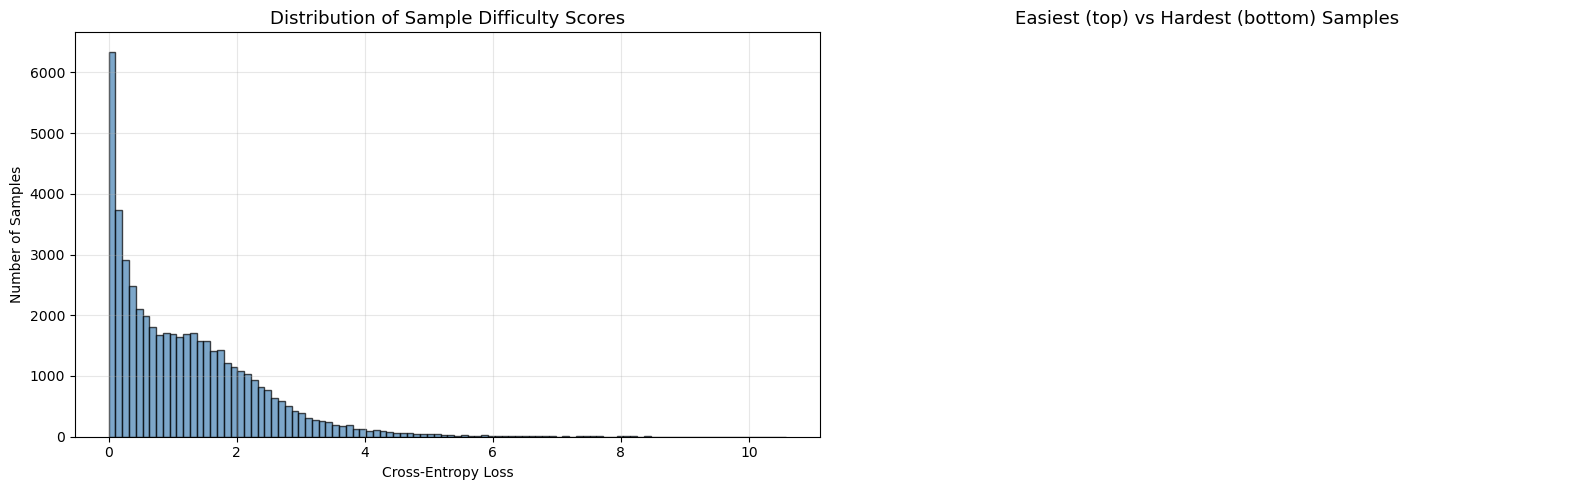

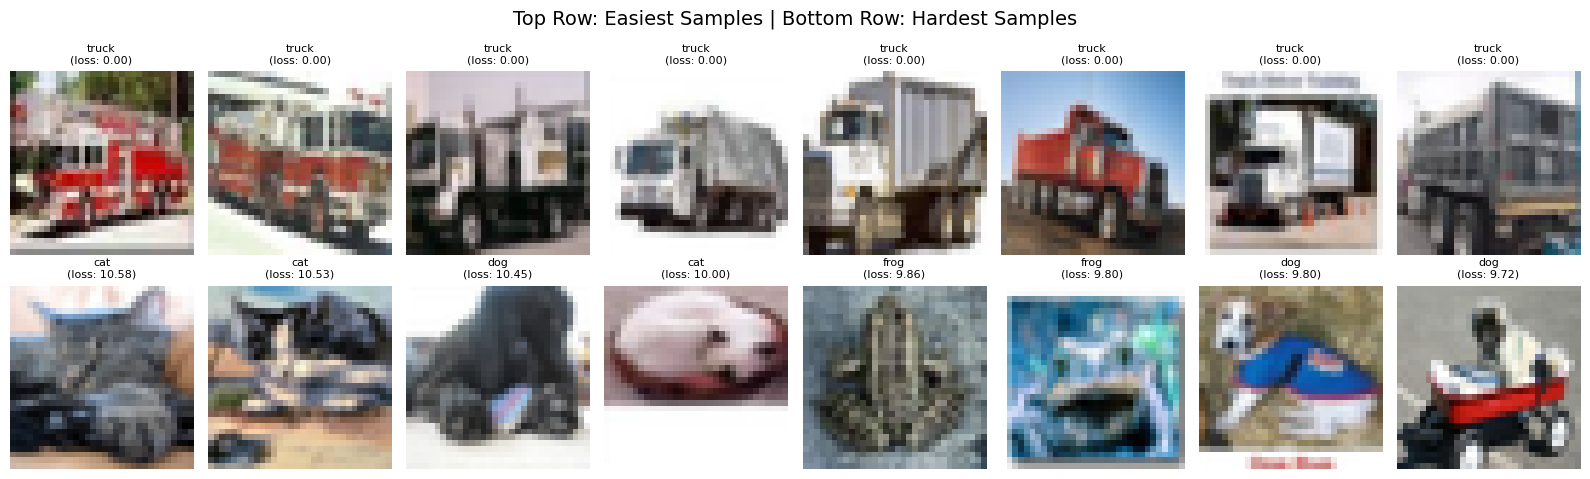

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of difficulty scores
axes[0].hist(per_sample_loss, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Sample Difficulty Scores', fontsize=13)
axes[0].set_xlabel('Cross-Entropy Loss')
axes[0].set_ylabel('Number of Samples')
axes[0].grid(True, alpha=0.3)

# Show examples of easiest and hardest samples
axes[1].set_title('Easiest (top) vs Hardest (bottom) Samples', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Show easiest and hardest samples side by side
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Top Row: Easiest Samples | Bottom Row: Hardest Samples', fontsize=14)

for i in range(8):
    # Easiest
    axes[0, i].imshow(x_train_sorted[i])
    true_label = int(y_train_sorted[i][0])
    axes[0, i].set_title(f'{class_names[true_label]}\n(loss: {loss_sorted[i]:.2f})', fontsize=8)
    axes[0, i].axis('off')
    
    # Hardest
    idx = -(i + 1)
    axes[1, i].imshow(x_train_sorted[idx])
    true_label = int(y_train_sorted[idx][0])
    axes[1, i].set_title(f'{class_names[true_label]}\n(loss: {loss_sorted[idx]:.2f})', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Part 4 - Curriculum Training

Now we train a fresh model using the curriculum (easy → hard) ordering.
The model is trained in 5 stages, progressively adding harder samples.

In [27]:
# Curriculum schedule: fraction of data at each stage (easiest first)
curriculum_fractions = [0.20, 0.40, 0.60, 0.80, 1.00]
epochs_per_stage = 5  # 5 stages × 5 epochs = 25 total epochs

print("Curriculum Learning Schedule (Easy → Hard):")
print("="*60)
for i, frac in enumerate(curriculum_fractions):
    n_samples = int(len(x_train_sorted) * frac)
    start_loss = loss_sorted[0]
    end_loss = loss_sorted[n_samples - 1]
    print(f"Stage {i+1}: Easiest {frac*100:.0f}% → {n_samples:,} samples "
          f"(loss range: {start_loss:.3f} - {end_loss:.3f}) ({epochs_per_stage} epochs)")
print(f"\nTotal epochs: {len(curriculum_fractions) * epochs_per_stage}")

Curriculum Learning Schedule (Easy → Hard):
Stage 1: Easiest 20% → 10,000 samples (loss range: 0.000 - 0.209) (5 epochs)
Stage 2: Easiest 40% → 20,000 samples (loss range: 0.000 - 0.659) (5 epochs)
Stage 3: Easiest 60% → 30,000 samples (loss range: 0.000 - 1.284) (5 epochs)
Stage 4: Easiest 80% → 40,000 samples (loss range: 0.000 - 2.022) (5 epochs)
Stage 5: Easiest 100% → 50,000 samples (loss range: 0.000 - 10.581) (5 epochs)

Total epochs: 25


In [29]:
# Build and compile a fresh model for curriculum training
cnn = build_cnn()
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,658 (1014.29 KB)

 Trainable params: 259,210 (1012.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [31]:
# Store full training history across all stages
full_history = {
    'accuracy': [],
    'val_accuracy': [],
    'loss': [],
    'val_loss': []
}

stage_boundaries = []  # to mark where each stage starts in the plot

for stage_idx, fraction in enumerate(curriculum_fractions):
    n_samples = int(len(x_train_sorted) * fraction)
    
    # Take the easiest n_samples (curriculum ordering)
    x_subset = x_train_sorted[:n_samples]
    y_subset = y_train_sorted[:n_samples]
    
    # Create augmented training set for this stage
    training_set = train_datagen.flow(x_subset, y_subset, batch_size=64)
    
    start_loss = loss_sorted[0]
    end_loss = loss_sorted[n_samples - 1]
    
    print(f"\n{'='*70}")
    print(f"STAGE {stage_idx + 1}/{len(curriculum_fractions)}: "
          f"Training with easiest {fraction*100:.0f}% ({n_samples:,} samples)")
    print(f"Loss range: {start_loss:.3f} - {end_loss:.3f}")
    print(f"{'='*70}")
    
    # Record stage boundary for plotting
    stage_boundaries.append(len(full_history['accuracy']))
    
    # Train for epochs_per_stage epochs
    history = cnn.fit(
        x=training_set,
        validation_data=test_set,
        epochs=epochs_per_stage
    )
    
    # Accumulate history
    for key in full_history:
        full_history[key].extend(history.history[key])
    
    # Print stage summary
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"\nStage {stage_idx + 1} Complete:")
    print(f"  Train Accuracy: {final_train_acc:.4f}")
    print(f"  Val Accuracy:   {final_val_acc:.4f}")

print(f"\n{'='*70}")
print("Curriculum learning complete!")
print(f"{'='*70}")


STAGE 1/5: Training with easiest 20% (10,000 samples)
Loss range: 0.000 - 0.209
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5413 - loss: 1.4387 - val_accuracy: 0.1000 - val_loss: 6.9050
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8149 - loss: 0.5282 - val_accuracy: 0.1854 - val_loss: 5.0633
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8680 - loss: 0.3900 - val_accuracy: 0.4114 - val_loss: 2.6515
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9030 - loss: 0.2982 - val_accuracy: 0.3919 - val_loss: 3.4878
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9120 - loss: 0.2521 - val_accuracy: 0.3984 - val_loss: 3.4344

Stage 1 Complete:
  Train Accuracy: 0.9161
  Val Accuracy:   0.3984

STAGE 2/5: Training with easiest 40% (20,000 samples)
Loss range: 0.000 - 0.659
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.7966 - loss: 0.6306 - val_accuracy: 0.4134 - val_loss: 2.7367


## Part 5 - Evaluating the Results

### Plotting Training & Validation Accuracy / Loss with Stage Boundaries

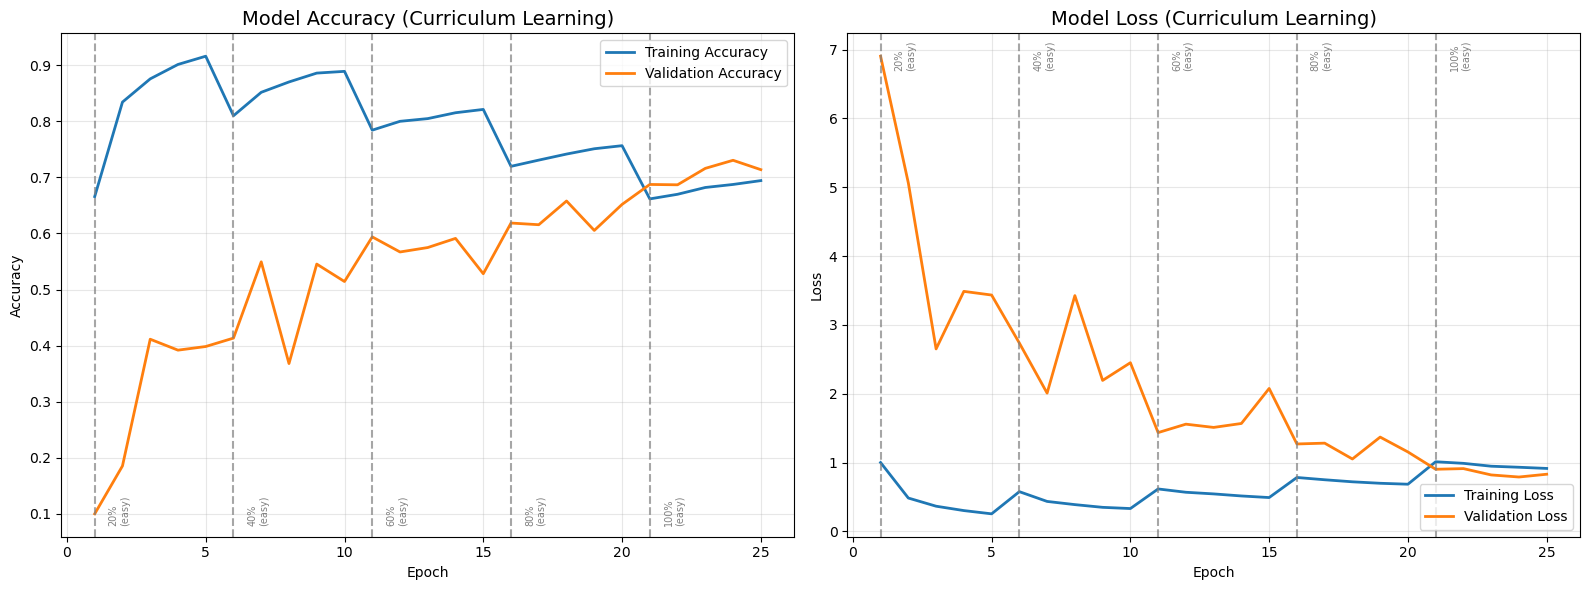

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(full_history['accuracy']) + 1)

# --- Accuracy plot ---
ax1.plot(epochs_range, full_history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(epochs_range, full_history['val_accuracy'], label='Validation Accuracy', linewidth=2)

# Add stage boundary lines
for i, boundary in enumerate(stage_boundaries):
    frac = curriculum_fractions[i]
    ax1.axvline(x=boundary + 1, color='gray', linestyle='--', alpha=0.7)
    ax1.text(boundary + 1.5, ax1.get_ylim()[0] + 0.02, f'{frac*100:.0f}%\n(easy)',
             fontsize=7, color='gray', rotation=90, va='bottom')

ax1.set_title('Model Accuracy (Curriculum Learning)', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Loss plot ---
ax2.plot(epochs_range, full_history['loss'], label='Training Loss', linewidth=2)
ax2.plot(epochs_range, full_history['val_loss'], label='Validation Loss', linewidth=2)

# Add stage boundary lines
for i, boundary in enumerate(stage_boundaries):
    frac = curriculum_fractions[i]
    ax2.axvline(x=boundary + 1, color='gray', linestyle='--', alpha=0.7)
    ax2.text(boundary + 1.5, ax2.get_ylim()[1] - 0.1, f'{frac*100:.0f}%\n(easy)',
             fontsize=7, color='gray', rotation=90, va='top')

ax2.set_title('Model Loss (Curriculum Learning)', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Final Test set evaluation

In [35]:
test_loss, test_accuracy = cnn.evaluate(x_test / 255.0, y_test)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7172 - loss: 0.8307

Test Loss     : 0.8304
Test Accuracy : 0.7138


In [37]:
cnn.save('cifar10_curriculum_model.keras')

## Part 6 - Making a single prediction

In [39]:
idx = np.random.randint(0, len(x_test))
test_image = x_test[idx]

# Preprocess: rescale and add batch dimension
test_image_input = test_image.astype('float32') / 255.0
test_image_input = np.expand_dims(test_image_input, axis=0)

# Predict
result = cnn.predict(test_image_input)
predicted_class = np.argmax(result[0])
confidence = result[0][predicted_class] * 100
actual_class = int(y_test[idx][0])

print(f"Predicted class : {class_names[predicted_class]} ({confidence:.1f}% confidence)")
print(f"Actual class    : {class_names[actual_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Predicted class : deer (44.8% confidence)
Actual class    : deer


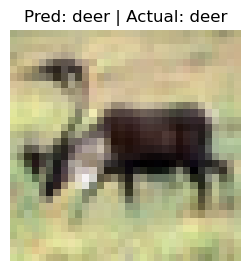

In [41]:
plt.figure(figsize=(3, 3))
plt.imshow(test_image)
plt.title(f"Pred: {class_names[predicted_class]} | Actual: {class_names[actual_class]}")
plt.axis('off')
plt.show()